#**스마트폰 센서 데이터 기반 모션 분류**
# 단계2 : 기본 모델링


## 0.미션3

* 데이터 전처리
    * 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리 수행
* 다양한 딥러닝 구조의 모델로 분류 모델 생성
    * 최소 4개 이상 모델링 수행
    * (옵션)각 모델별 최소 5회 반복수행해서 얻은 성능의 평균으로 비교
    * (옵션)각 모델의 성능을 저장하는 별도 데이터 프레임을 만들고 비교
* 옵션 : 다음 사항은 선택사항입니다. 시간이 허용하는 범위 내에서 수행하세요.
    * 상위 N개 변수를 선정하여 모델링 및 성능 비교
        * 모델링에 항상 모든 변수가 필요한 것은 아닙니다.
        * 변수 중요도 상위 N개를 선정하여 모델링하고 타 모델과 성능을 비교하세요.
        * 상위 N개를 선택하는 방법은, 변수를 하나씩 늘려가며 모델링 및 성능 검증을 수행하여 적절한 지점을 찾는 것입니다.
* 성능 가이드
    * Accuracy : 0.90 ~ 0.99

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
path = '/content/drive/MyDrive/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

from keras.regularizers import l1, l2
from keras.callbacks import ModelCheckpoint, EarlyStopping

from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau
import math

from keras.layers import BatchNormalization

In [23]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [24]:
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')
features = pd.read_csv(path + 'features.csv')

In [25]:
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS


In [26]:
# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

#### 2) 기본 정보 조회

In [27]:
# 전체 데이터의 행, 열 개수 확인
df_train.shape

(5881, 562)

In [28]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


In [29]:
# 전체 데이터의 수치형 변수 분포 확인
df_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [30]:
# 전체 데이터의 모든 변수 확인
df_train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'Activity'],
      dtype='object', length=562)

In [31]:
null_columns = df_train.isnull().sum()
null_columns[null_columns > 0]

,0


## **2. 데이터 전처리**

* 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리를 수행한다.


### (1) 데이터 분할1 : x, y

* 세부 요구사항
    - x, y로 분할합니다.

In [32]:
target = 'Activity'
x1 = df_train.drop(columns=target)
y1 = df_train.loc[:, target]

### (2) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [33]:
# train, val 분할 후 스케일링 진행

### (3) Y 전처리
* integer encoding : LabelEncoder
* (필요시) one-hot encoding

In [34]:
y1

,Activity
0,STANDING
1,LAYING
2,STANDING
3,WALKING
4,WALKING_DOWNSTAIRS
...,...
5876,SITTING
5877,WALKING_UPSTAIRS
5878,LAYING
5879,WALKING_UPSTAIRS


In [35]:
y1.unique()

array(['STANDING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS', 'SITTING'], dtype=object)

In [36]:
# 범주형 데이터를 정수로 변환하기 위함./ 모델링 시 수치 데이터만 처리할 수 있기 때문
# 예를 들어, ['apple', 'banana', 'cherry']와 같은 범주형 데이터가 있을 때 이를 [0, 1, 2]로 변환한다.
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y1)  # 데이터를 학습하고 범주형 데이터를 정수형으로 바꾼다.
y_encoded

array([2, 0, 2, ..., 0, 5, 1])

### (4) 데이터분할2 : train, validation

* 세부 요구사항
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

In [37]:
x_train, x_val, y_train, y_val = train_test_split(x1, y_encoded, test_size=0.3, random_state=42)

In [39]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [19]:
x_train

array([[0.51785664, 0.39734693, 0.44165638, ..., 0.21924457, 0.85201872,
        0.63442145],
       [0.51933212, 0.39468318, 0.44449917, ..., 0.09876538, 0.83325484,
        0.49368441],
       [0.535798  , 0.38477188, 0.47091267, ..., 0.10215916, 0.82122963,
        0.54487396],
       ...,
       [0.51822274, 0.39687638, 0.44764277, ..., 0.06535379, 0.68260814,
        0.517862  ],
       [0.52239007, 0.39637246, 0.44675376, ..., 0.88884493, 0.82251721,
        0.99503925],
       [0.55320838, 0.39795343, 0.43792303, ..., 0.11034188, 0.81856718,
        0.55699251]])

## **3. 기본 모델링**



* 세부 요구사항
    - 모델1 : Base line 모델
        * Hidden Layer 없이 모델 생성
    - 모델2 : 복잡한 모델 생성
        * 최소 5개 이상의 은닉층을 추가한 모델
    - 모델3 ~ n : 튜닝 모델
        * 학습률, epoch 등 조정
        * 모델2에 과적합을 방지하기 위한 규제 기법 추가
        * Accuracy 최대화 시키는 모델 생성하기
    - 각 모델은 최소 5번 반복수행해서 얻은 성능의 평균값을 기록

### (1) 모델1

In [40]:
x_train.shape

(4116, 561)

In [41]:
# 특성 수 출력
nfeatures = x_train.shape[1]
nfeatures

561

In [42]:
clear_session()

In [ ]:
# 모델 선언
model1 = Sequential([Input(shape=(nfeatures, )),
                     Dense(6, activation='softmax')])
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │           3,372 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,372 (13.17 KB)

 Trainable params: 3,372 (13.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9312 - val_loss: 0.4167
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3338 - val_loss: 0.3150
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2266 - val_loss: 0.2841
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1976 - val_loss: 0.2754
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2024 - val_loss: 0.1902
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1337 - val_loss: 0.1962
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1294 - val_loss: 0.1544
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1407 - val_loss: 0.1419
Epoch 9/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1017 - val_loss: 0.1332
Epoch 10/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1151 - val_loss: 0.1432
Epoch 11/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1168 - val_loss: 0.1369
Epoch 12/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

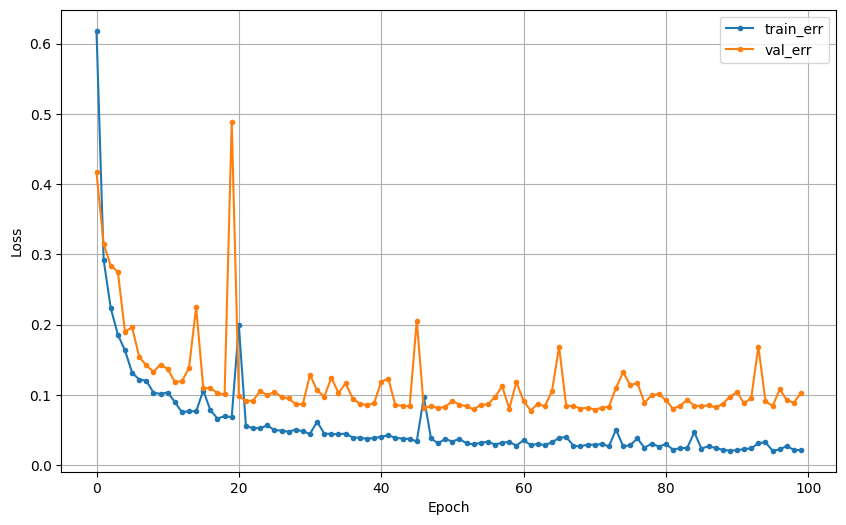

In [ ]:
# 모델 컴파일
model1.compile(optimizer=Adam(learning_rate = 0.01), loss = 'sparse_categorical_crossentropy')

# 모델 학습
history1 = model1.fit(x_train, y_train, epochs=100, validation_split = 0.3).history   # verbose = 0 : 학습과정 안보이게

dl_history_plot(history1)

In [ ]:
# 예측
pred1 = model1.predict(x_val)   #  확률 값으로 출력됨
pred_1 = np.argmax(pred1, axis = 1)

# 평가
print(confusion_matrix(y_val, pred_1))
print(classification_report(y_val, pred_1))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[334   0   0   0   0   0]
 [  3 304   2   0   0   1]
 [  0  37 276   0   0   0]
 [  0   0   0 290   1   1]
 [  0   0   0   0 237   2]
 [  0   0   0   1   0 276]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       334
           1       0.89      0.98      0.93       310
           2       0.99      0.88      0.93       313
           3       1.00      0.99      0.99       292
           4       1.00      0.99      0.99       239
           5       0.99      1.00      0.99       277

    accuracy                           0.97      1765
   macro avg       0.98      0.97      0.97      1765
weighted avg       0.97      0.97      0.97      1765



### (2) 모델2

In [ ]:
nfeatures

561

In [ ]:
model2 = Sequential([Input(shape = (nfeatures, )),
                     Dense(128, activation = 'relu'),
                     Dense(64, activation = 'relu'),
                     Dense(32, activation = 'relu'),
                     Dense(16, activation = 'relu'),
                     Dense(8, activation = 'relu'),
                     Dense(6, activation = 'softmax')
                     ])
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 6)                   │              54 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,990 (324.18 KB)

 Trainable params: 82,990 (324.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 컴파일
model2.compile(optimizer=Adam(learning_rate = 0.01), loss = 'sparse_categorical_crossentropy')

In [ ]:
# 모델 학습
history2 = model2.fit(x_train, y_train, epochs=100, validation_split = 0.3, verbose = 0).history   # verbose = 0 : 학습과정 안보이게

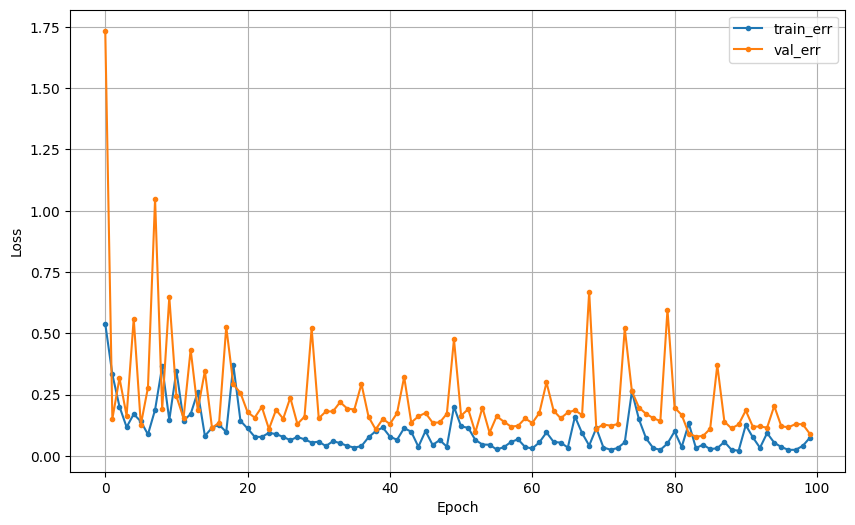

In [ ]:
dl_history_plot(history2)

In [ ]:
# 예측
pred2 = model2.predict(x_val)
pred_2 = np.argmax(pred2, axis = 1)

# 평가
print(confusion_matrix(y_val, pred_2))
print(classification_report(y_val, pred_2))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[334   0   0   0   0   0]
 [  4 300   6   0   0   0]
 [  0  23 290   0   0   0]
 [  0   0   0 288   0   4]
 [  0   0   0   0 233   6]
 [  0   0   0   1   0 276]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       334
           1       0.93      0.97      0.95       310
           2       0.98      0.93      0.95       313
           3       1.00      0.99      0.99       292
           4       1.00      0.97      0.99       239
           5       0.97      1.00      0.98       277

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765



### (3) 모델3

learning rate - step decay

In [131]:
# Step decay function
def step_decay(epoch):
    initial_lr = 0.001  # 초기 learning rate
    drop = 0.5         # learning rate 감소 비율
    epochs_drop = 10    # 몇 에포크마다 감소할지 설정
    lr = initial_lr * math.pow(drop, math.floor((1 + epoch) / epochs_drop))
    return lr

In [141]:
# LearningRateScheduler 콜백 생성
# lr_scheduler = LearningRateScheduler(step_decay)

# 학습 중 학습률 자동 감소
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [142]:
clear_session()

dropout_num = 0.2

model3 = Sequential([Input(shape = (nfeatures, )),
                     Dense(128, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(64, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(32, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(16, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(8, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(6, activation = 'softmax')
                     ])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              54 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,982 (328.05 KB)

 Trainable params: 83,486 (326.12 KB)

 Non-trainable params: 496 (1.94 KB)

In [143]:
model3.compile(optimizer=Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

# cp_path = '/content/{epoch:03d}.keras'  # Keras 2.11 이상 버전에서 모델 확장자 .keras
# mcp = ModelCheckpoint(cp_path, monitor='val_loss', verbose = 1, save_best_only=True)


# EarlyStopping 설정 ------------
# min_delta 보다 개선이 안 됐으면 patience가 증가한다!!
min_de = 0.005  # 오차(loss)가 0.001이 되면 못참아.
pat = 5         # 5번까지는 오차 올라가는거 봐줄게.

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)
# --------------------------------


history3 = model3.fit(x_train, y_train, epochs=150, validation_split = 0.3, callbacks = [es, lr_scheduler]).history  # , callbacks = [mcp]

Epoch 1/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2995 - loss: 1.7719 - val_accuracy: 0.4348 - val_loss: 1.6176 - learning_rate: 0.0010
Epoch 2/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5939 - loss: 1.1516 - val_accuracy: 0.7684 - val_loss: 0.9157 - learning_rate: 0.0010
Epoch 3/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7259 - loss: 0.8716 - val_accuracy: 0.8794 - val_loss: 0.4890 - learning_rate: 0.0010
Epoch 4/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8059 - loss: 0.6698 - val_accuracy: 0.9166 - val_loss: 0.3313 - learning_rate: 0.0010
Epoch 5/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8484 - loss: 0.5496 - val_accuracy: 0.8972 - val_loss: 0.3163 - learning_rate: 0.0010
Epoch 6/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8639 - loss: 0.4872 - val_accuracy: 0.9368 - val_loss: 0.2054 - learning_rate: 0.0010
Epoch 7/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8838 - loss: 0.4154 - val_a

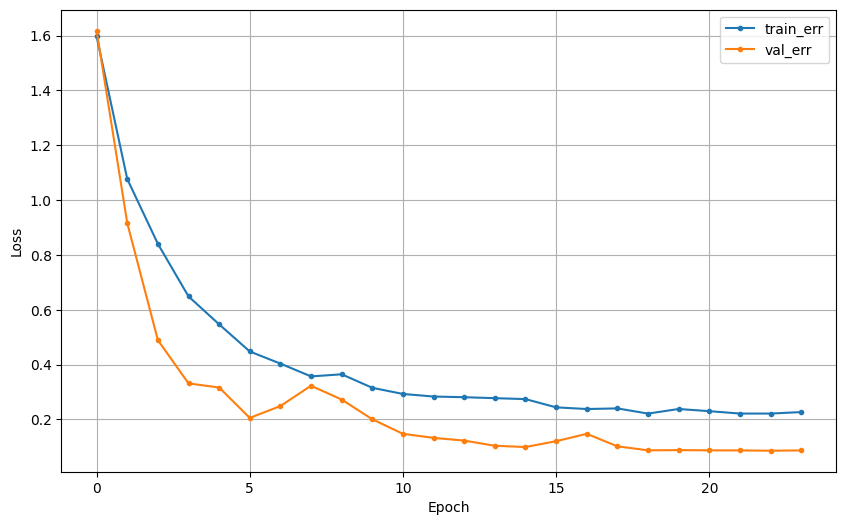

In [147]:
dl_history_plot(history3)

In [148]:
pred3 = model3.predict(x_val)
pred_3 = np.argmax(pred3, axis = 1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [149]:
print(confusion_matrix(y_val, pred_3))
print(classification_report(y_val, pred_3))

[[334   0   0   0   0   0]
 [  0 304   6   0   0   0]
 [  0  23 290   0   0   0]
 [  0   0   0 289   0   3]
 [  0   0   0   0 237   2]
 [  0   0   0   1   1 275]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       334
           1       0.93      0.98      0.95       310
           2       0.98      0.93      0.95       313
           3       1.00      0.99      0.99       292
           4       1.00      0.99      0.99       239
           5       0.98      0.99      0.99       277

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765



### (4) 모델4

-

## 4.성능비교

* 세부 요구사항
    - test 데이터에 대한 전처리
    - 각 모델에 대해서 test 데이터로 성능 측정